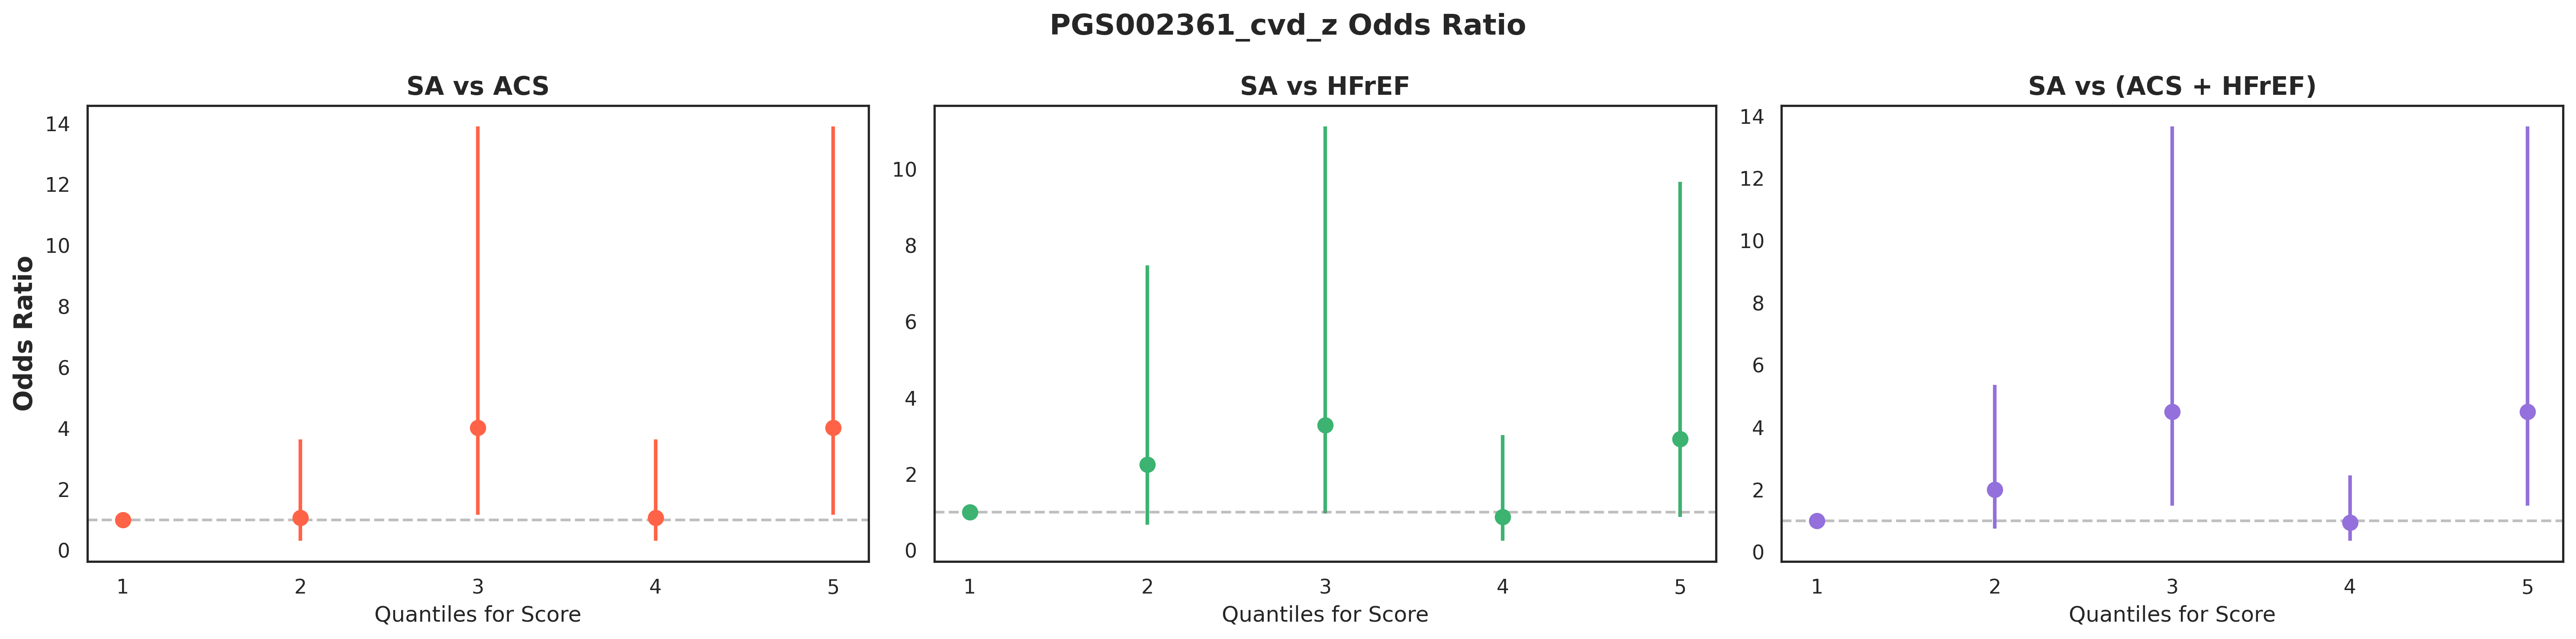

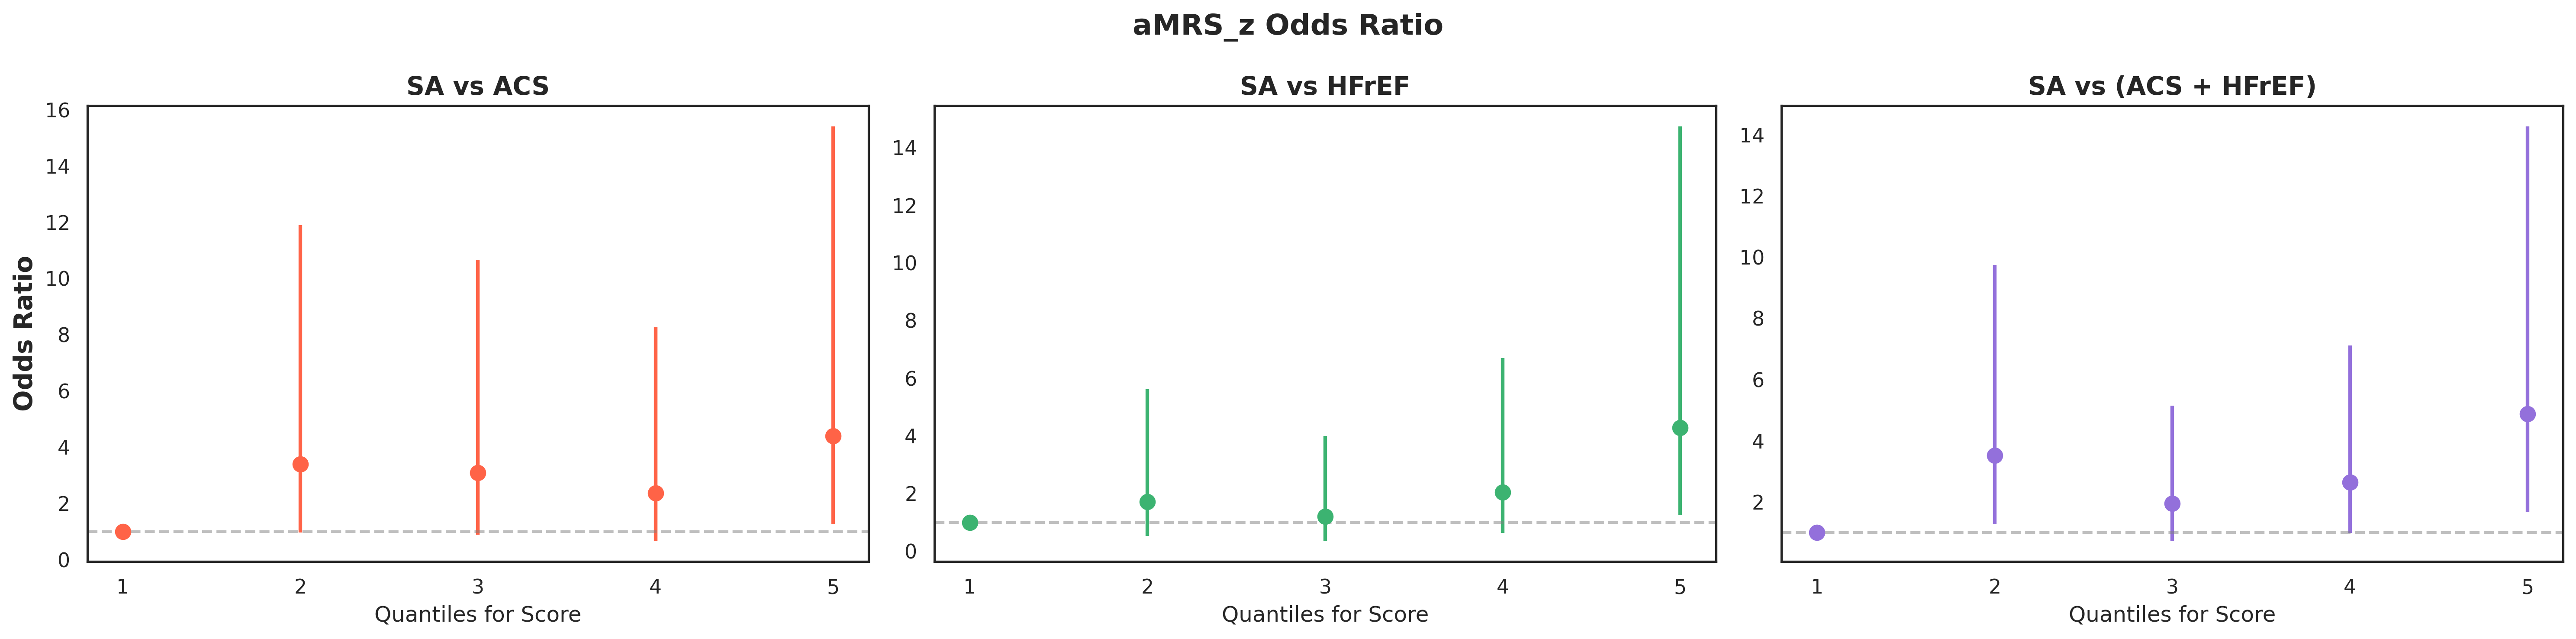

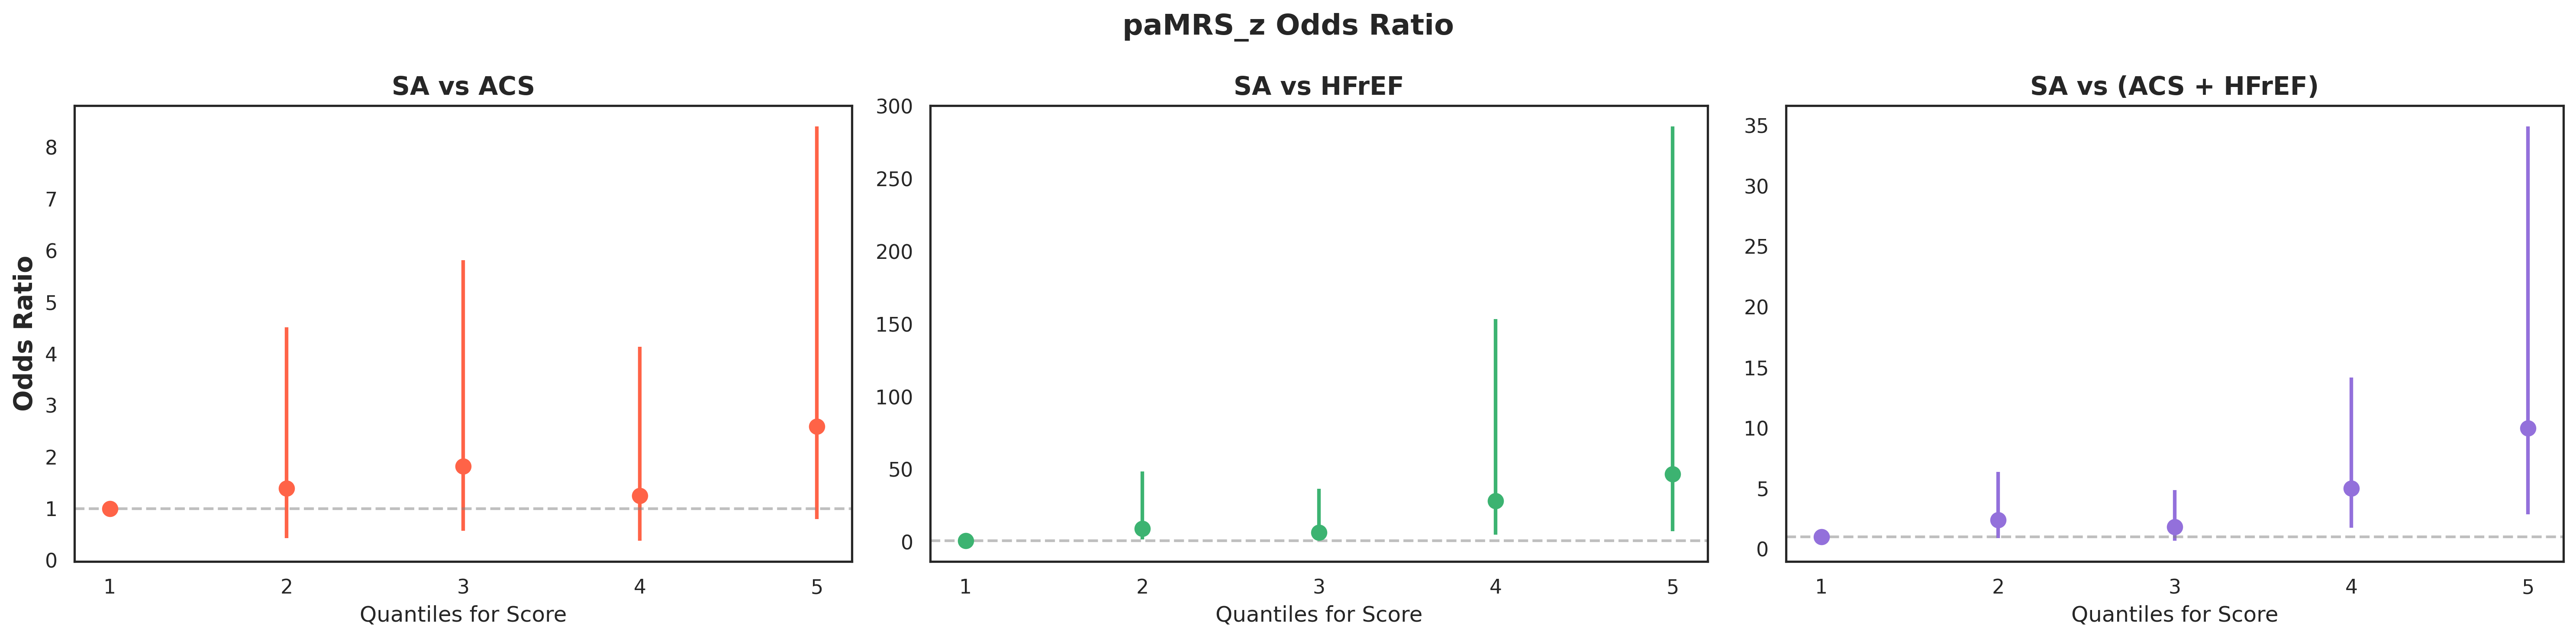

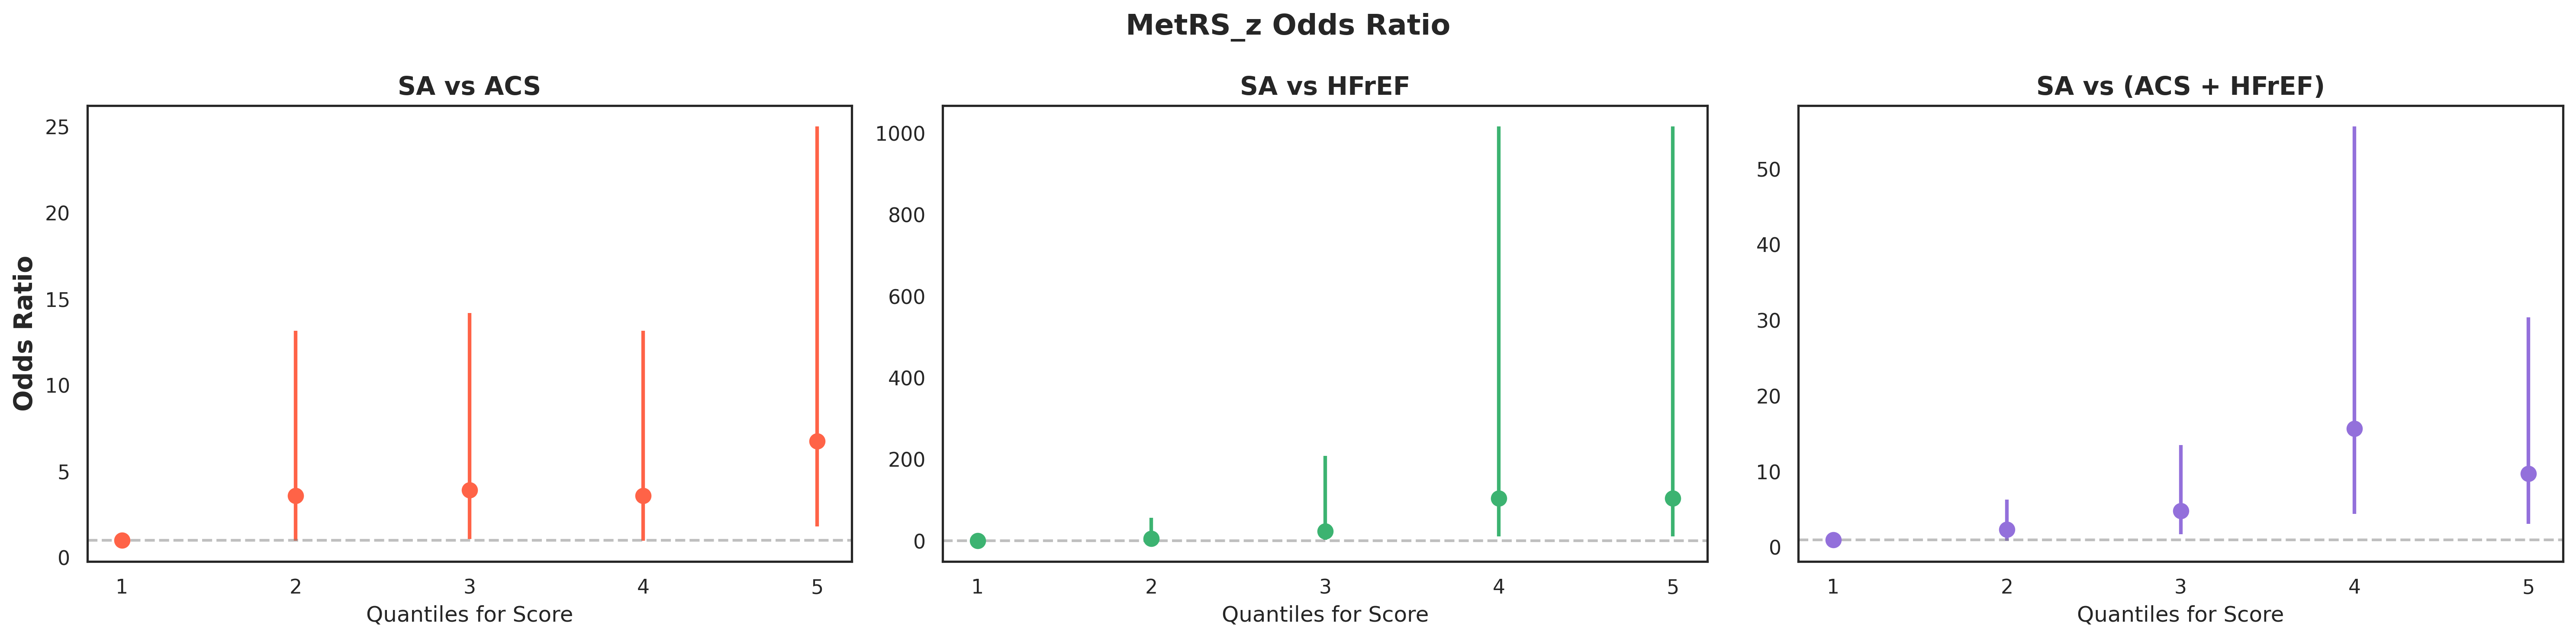

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('default')
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Load metadata and calculated scores from the specified input directories
meta_df = pd.read_csv('/path/to/input/metadata.tsv', sep='\t')
scores_df = pd.read_csv('/path/to/input/merged_scores.tsv', sep='\t')
df = pd.merge(meta_df, scores_df, on=['SampleID', 'Group'])

# Create a combined disease group (ACS + HFrEF) for comparison
others_df = df[df['Group'].isin(['ACS', 'HFrEF'])].copy()
others_df['Group'] = '(ACS + HFrEF)'
df = pd.concat([df, others_df], ignore_index=True)

scores_list = ['PGS002361_cvd_z', 'aMRS_z', 'paMRS_z', 'MetRS_z']
control_group = 'SA'
disease_groups = ['ACS', 'HFrEF', '(ACS + HFrEF)']

num_quantiles = 5
ref_quantile = 1

def calculate_or_ci(data, target_score, target_group, ref_group):
    sub_df = data[data['Group'].isin([target_group, ref_group])].dropna(subset=[target_score]).copy()
    sub_df['Quantile'] = pd.qcut(sub_df[target_score], q=num_quantiles, labels=False, duplicates='drop') + 1
    sub_df['Outcome'] = np.where(sub_df['Group'] == target_group, 1, 0)
    
    formula = f"Outcome ~ C(Quantile, Treatment(reference={ref_quantile}))"
    
    try:
        model = sm.Logit.from_formula(formula, data=sub_df).fit(disp=0)
    except Exception:
        return None
    
    params = model.params
    conf = model.conf_int()
    
    results = []
    for q in range(1, num_quantiles + 1):
        if q == ref_quantile:
            results.append({'Quantile': q, 'OR': 1.0, 'Lower_CI': 1.0, 'Upper_CI': 1.0})
        else:
            var_name = f"C(Quantile, Treatment(reference={ref_quantile}))[T.{q}]"
            if var_name in params:
                or_val = np.exp(params[var_name])
                lower = np.exp(conf.loc[var_name, 0])
                upper = np.exp(conf.loc[var_name, 1])
                results.append({'Quantile': q, 'OR': or_val, 'Lower_CI': lower, 'Upper_CI': upper})
    return pd.DataFrame(results)

colors = ['#FF6347', '#3CB371', '#9370DB']

# Ensure output directory exists for plots
output_dir = '/path/to/output/plot'
os.makedirs(output_dir, exist_ok=True)

for score_col in scores_list:
    fig, axes = plt.subplots(1, len(disease_groups), figsize=(20, 5), dpi=300)
    
    for j, disease in enumerate(disease_groups):
        ax = axes[j]
        res_df = calculate_or_ci(df, score_col, disease, control_group)
        
        if res_df is None or res_df.empty:
            ax.set_title(f"{control_group} vs {disease} - Data Error", fontsize=12)
            continue
            
        lower_error = res_df['OR'] - res_df['Lower_CI']
        upper_error = res_df['Upper_CI'] - res_df['OR']
        errors = [lower_error, upper_error]
        
        ax.errorbar(x=res_df['Quantile'], y=res_df['OR'], yerr=errors, 
                    fmt='o', color=colors[j], ecolor=colors[j], capsize=0, elinewidth=2, markersize=8)
        
        ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
        ax.set_title(f"{control_group} vs {disease}", fontsize=14, fontweight='bold')
        ax.set_xticks(range(1, num_quantiles + 1))
        
        ax.set_xlabel("Quantiles for Score", fontsize=12)
        ax.set_xticklabels(range(1, num_quantiles + 1), rotation=0) 
            
        if j == 0:
            ax.set_ylabel("Odds Ratio", fontsize=14, fontweight='bold')

    fig.suptitle(f"{score_col} Odds Ratio", fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    # Save plots to the designated output path
    plt.savefig(f'{output_dir}/{score_col}_odds_ratio.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{output_dir}/{score_col}_odds_ratio.pdf', bbox_inches='tight')
    
    plt.show()